# Forecasting International Student Mobility

**Group 26:** Adriano Machado, Francisco da Ana, João Lopes, Tiago Teixeira

ESN Porto is a non-profit that supports international exchange students in Porto. Students who buy a membership card get discounts at local businesses, invitations to social events, and access to cultural activities.

We analyzed five years of membership data to identify trends and forecast weekly sign-ups. Better predictions mean ESN Porto can staff appropriately, having enough volunteers ready when students need help most, and schedule events when demand is highest.

Since membership patterns track closely with international student arrivals, this analysis also gives us insight into broader mobility trends in Porto's academic community.

## 1. Introduction & Exploratory Data Analysis

In [18]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta

# Models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet

# Validation & Selection
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_selection import RFECV
import optuna
import warnings

In [19]:
DATA_DIR = Path('data')
FIGURES_DIR = Path('figures')
RESULTS_DIR = Path('results')
FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# Configuration: Set to True to run hyperparameter tuning, False to load from saved results
RUN_HYPERPARAMETER_TUNING = True

# We split at 2024 for the validation phase. 
# 2021-2023: Feature Selection & Initial Training
# 2024: Hyperparameter Optimization (Validation)
# 2025: Final Test (Held out)
SPLIT_DATE = '2024-01-01'

In [20]:
with open(DATA_DIR / 'eventupp_students_private.json', 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data)

print(f"Loaded data from: {DATA_DIR / 'eventupp_students_private.json'}")
print(f"Total students: {len(df):,}")

# Convert registerDate from milliseconds to datetime
df['registerDate'] = pd.to_datetime(df['registerDate'], unit='ms')
df_ts = df.set_index('registerDate').sort_index()

# Aggregate weekly - count registrations per week
weekly_registrations = df_ts.resample('W').size()

# Create a DataFrame with weekly aggregation
weekly_df = pd.DataFrame({
    'week_ending': weekly_registrations.index,
    'registrations': weekly_registrations.values
})

Loaded data from: data/eventupp_students_private.json
Total students: 14,168


In [21]:
print(f"\nWeekly aggregation:")
print(f"Total weeks: {len(weekly_df)}")
print(f"Date range: {weekly_df['week_ending'].min()} to {weekly_df['week_ending'].max()}")
print(f"\nFirst 10 weeks:")
weekly_df.head(10)


Weekly aggregation:
Total weeks: 227
Date range: 2021-08-08 00:00:00 to 2025-12-07 00:00:00

First 10 weeks:


,week_ending,registrations
0,2021-08-08,17
1,2021-08-15,22
2,2021-08-22,15
3,2021-08-29,18
4,2021-09-05,196
5,2021-09-12,246
6,2021-09-19,190
7,2021-09-26,145
8,2021-10-03,172
9,2021-10-10,71


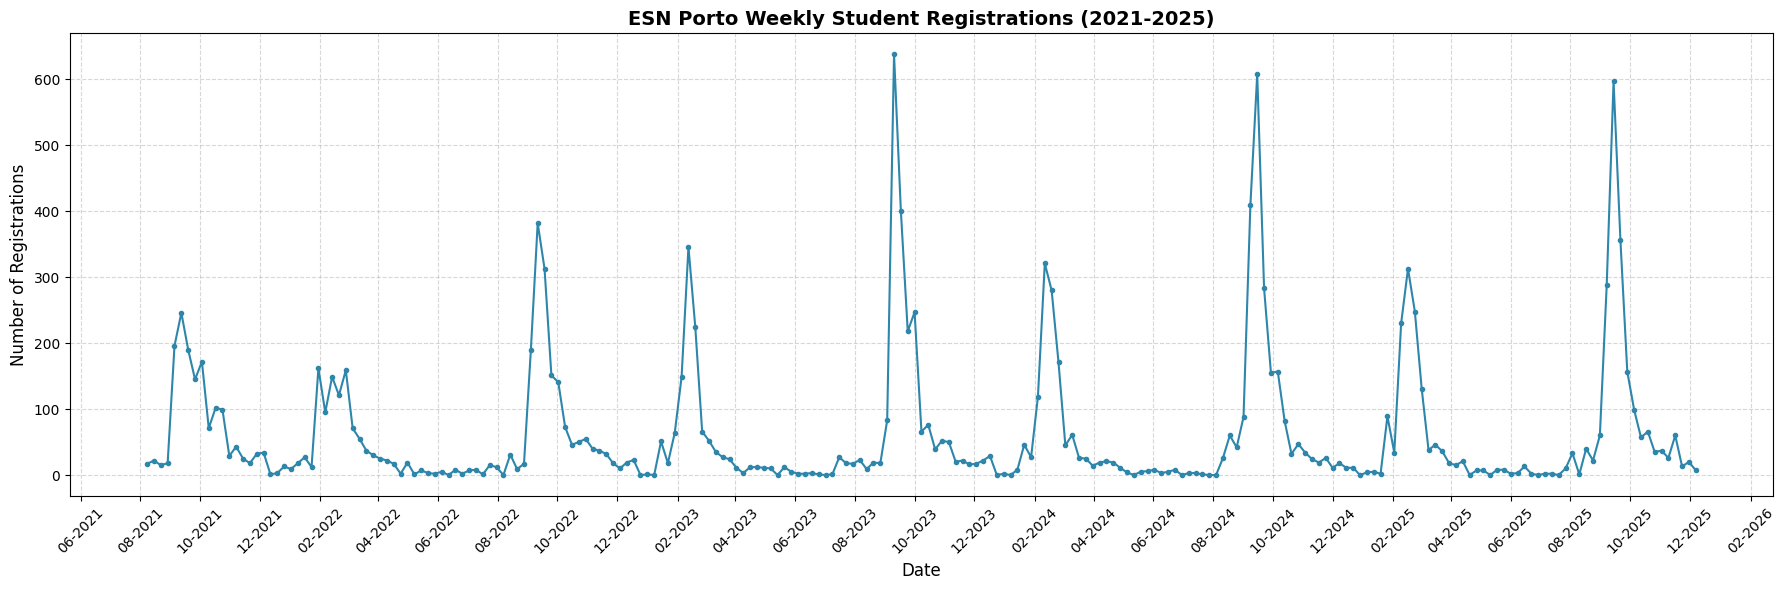

In [22]:
fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(weekly_df['week_ending'], weekly_df['registrations'], 
        linewidth=1.5, color='#2E86AB', marker='o', markersize=3)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Registrations', fontsize=12)
ax.set_title('ESN Porto Weekly Student Registrations (2021-2025)', fontsize=14, fontweight='bold')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha='center')
ax.grid(True, alpha=0.5, linestyle='--')
plt.tight_layout()

plt.savefig(FIGURES_DIR / 'weekly_registrations.png')
plt.show()

## 2. Methodology

The data shows that most days have few or no registrations, but there are distinct seasonal peaks. 

We treated the problem as a regression task. To improve performance, we made significant changes to the standard approach:

1.  **Stationarity:** Instead of predicting the raw number of registrations, we predict the **Weekly Change** (differencing). This allows tree-based models (like Random Forest) to handle trends better and prevents them from being bounded by historical maximums.
2.  **Metric:** We utilize **WMAPE** (Weighted Mean Absolute Percentage Error) instead of standard MAPE, as it handles weeks with zero registrations gracefully.
3.  **Strict Split:** We perform Feature Selection *only* on pre-2024 data to prevent data leakage.

The work involved four areas: Feature Engineering, Feature Selection (RFE), Model Selection (Walk-Forward Validation), and Hyperparameter Tuning.

### 2.1 Feature Engineering

We created a set of features to capture the temporal patterns in student registration behavior. 

* **Calendar Features:** Month, Week of Year, Semester timing (Fall vs Spring).
* **Lag Features:** Past values of the *weekly change* (e.g., "how much did registrations grow 1 week ago?").
* **Cyclical Encodings:** Sine/Cosine transformations for weeks and months.

In [23]:
weekly_df = weekly_df.reset_index(drop=True)

In [24]:
def create_features(df_input):
    df = df_input.copy()

    df['month'] = df['week_ending'].dt.month
    df['week_of_year'] = df['week_ending'].dt.isocalendar().week.astype(int)

    def calculate_week_of_semester(row):
        year = row['week_ending'].year
        month = row['week_ending'].month
        week_ending = row['week_ending']

        # Fall (starts Aug), Spring (starts Feb)
        if month >= 8: 
            semester_start = pd.Timestamp(year=year, month=8, day=1)
        elif month <= 7 and month >= 2:  
            semester_start = pd.Timestamp(year=year, month=2, day=1)
        else:  
            semester_start = pd.Timestamp(year=year-1, month=8, day=1)

        return max(0, (week_ending - semester_start).days // 7)

    df['week_of_semester'] = df.apply(calculate_week_of_semester, axis=1)

    # Cyclical Encoding
    df['week_sin'] = np.sin(2 * np.pi * df['week_of_year'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['week_of_year'] / 52)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # --- CHANGE: Target is now 'registrations' directly ---
    target_col = 'registrations'

    for lag in [1, 2, 3, 4, 52]: 
        # Renaming feature from lag_diff to lag_abs to reflect absolute values
        df[f'lag_abs_{lag}'] = df[target_col].shift(lag)

    df['roll_mean_4_abs'] = df[target_col].shift(1).rolling(window=4).mean() 
    df['roll_std_4_abs']  = df[target_col].shift(1).rolling(window=4).std()  

    return df.dropna()

df_features = create_features(weekly_df)

cols_ignore = ['week_ending', 'registrations', 'year']
candidate_features = [c for c in df_features.columns if c not in cols_ignore]

print(f"Features created ({len(candidate_features)}): {candidate_features}")

Features created (14): ['month', 'week_of_year', 'week_of_semester', 'week_sin', 'week_cos', 'month_sin', 'month_cos', 'lag_abs_1', 'lag_abs_2', 'lag_abs_3', 'lag_abs_4', 'lag_abs_52', 'roll_mean_4_abs', 'roll_std_4_abs']


Standard feature selection methods can accidentally "see" the future if we aren't careful. To avoid this, we perform **Recursive Feature Elimination (RFE)** utilizing *only* the training data (before 2024).

In [25]:
train_fs_mask = df_features['week_ending'] < SPLIT_DATE
X_fs = df_features.loc[train_fs_mask, candidate_features]

y_fs = df_features.loc[train_fs_mask, 'registrations']

print(f"\n Feature Selection ")
print(f"Training on range: {df_features.loc[train_fs_mask, 'week_ending'].min().date()} "
      f"to {df_features.loc[train_fs_mask, 'week_ending'].max().date()}")

tscv = TimeSeriesSplit(n_splits=5)
base_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)

selector = RFECV(
    estimator=base_model,
    step=1,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    min_features_to_select=5,
    n_jobs=-1
)

selector.fit(X_fs, y_fs)
selected_features = np.array(candidate_features)[selector.support_].tolist()

print(f"Selected {len(selected_features)} features: {selected_features}")


 Feature Selection 
Training on range: 2022-08-07 to 2023-12-31
Selected 5 features: ['lag_abs_1', 'lag_abs_2', 'lag_abs_3', 'lag_abs_52', 'roll_std_4_abs']



Optimal number of features: 5
Selected Features: ['lag_abs_1', 'lag_abs_2', 'lag_abs_3', 'lag_abs_52', 'roll_std_4_abs']


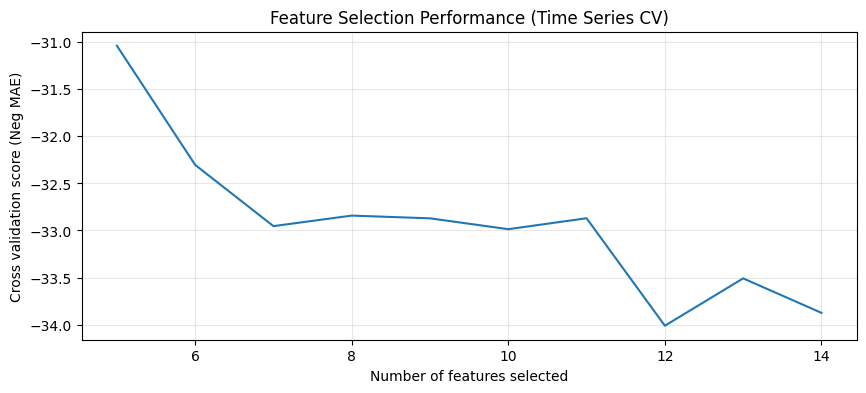

In [26]:
# 4. Extract Selected Features
selected_features = np.array(candidate_features)[selector.support_].tolist()

print(f"\nOptimal number of features: {selector.n_features_}")
print(f"Selected Features: {selected_features}")


# Create the final clean dataset with only selected features + metadata
final_cols = ['week_ending'] + selected_features + ['registrations']
df_clean = df_features[final_cols].copy()

# Visualizing Feature Selection Performance
plt.figure(figsize=(10, 4))
plt.xlabel("Number of features selected")
plt.ylabel("Cross validation score (Neg MAE)")
plt.plot(
    range(selector.min_features_to_select, 
          len(selector.cv_results_['mean_test_score']) + selector.min_features_to_select),
    selector.cv_results_['mean_test_score']
)
plt.title("Feature Selection Performance (Time Series CV)")
plt.grid(True, alpha=0.3)
plt.show()


### 2.2 Model Selection and Hyperparameter Tuning

We compare Random Forest, XGBoost, LightGBM, and ElasticNet.

We use **Bayesian Optimization** (Optuna) and a **Walk-Forward Validation** loop. This loop trains on history, predicts one week ahead, adds the actual data to the history, and repeats. This mimics exactly how the model will be used in production.

In [27]:
def wmape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

def walk_forward_cv(model, df, features, val_year):
    val_indices = df[df['week_ending'].dt.year == val_year].index

    if len(val_indices) == 0:
        return float('inf')

    predictions = []
    actuals = []

    for idx in val_indices:
        train_slice = df.loc[:idx-1]
        test_slice = df.loc[[idx]]

        X_train = train_slice[features]
        y_train = train_slice['registrations']

        X_test = test_slice[features]

        model.fit(X_train, y_train)
        
        pred_abs = max(0, model.predict(X_test)[0])

        actual_abs = df.loc[idx, 'registrations']
        predictions.append(pred_abs)
        actuals.append(actual_abs)

    return wmape(np.array(actuals), np.array(predictions))

In [28]:
def objective(trial):
    classifier_name = trial.suggest_categorical('classifier', ['RandomForest', 'XGBoost', 'LightGBM', 'ElasticNet'])

    if classifier_name == 'RandomForest':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
            'n_jobs': -1, 'random_state': 42
        }
        model = RandomForestRegressor(**params)

    elif classifier_name == 'XGBoost':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'max_depth': trial.suggest_int('max_depth', 2, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
            'n_jobs': -1, 'random_state': 42, 'verbosity': 0
        }
        model = XGBRegressor(**params)

    elif classifier_name == 'LightGBM':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'max_depth': trial.suggest_int('max_depth', 2, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
            'num_leaves': trial.suggest_int('num_leaves', 20, 100),
            'n_jobs': -1, 'random_state': 42, 'verbose': -1
        }
        model = LGBMRegressor(**params)

    elif classifier_name == 'ElasticNet':
        params = {
            'alpha': trial.suggest_float('alpha', 0.01, 10.0),
            'l1_ratio': trial.suggest_float('l1_ratio', 0.0, 1.0),
            'random_state': 42
        }
        model = ElasticNet(**params)

    score = walk_forward_cv(model, df_features.reset_index(drop=True), selected_features, val_year=2024)
    return score

In [29]:
print(f"\n Hyperparameter Optimization ")

if RUN_HYPERPARAMETER_TUNING:
    print("Running hyperparameter tuning...")
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=30)
    
    # Save the optimization results
    best_results = {
        'best_value': study.best_value,
        'best_params': study.best_params
    }
    
    results_path = RESULTS_DIR / 'hyperparameter_tuning_results.json'
    with open(results_path, 'w') as f:
        json.dump(best_results, f, indent=2)
    
    print(f"Results saved to: {results_path}")
    print(f"\nBest WMAPE: {study.best_value:.4f}")
    print(f"Best Model: {study.best_params}")
    
else:
    print("Loading hyperparameter tuning results from memory...")
    results_path = RESULTS_DIR / 'hyperparameter_tuning_results.json'
    
    if not results_path.exists():
        raise FileNotFoundError(
            f"No saved results found at {results_path}. "
            f"Please set RUN_HYPERPARAMETER_TUNING=True to run optimization first."
        )
    
    with open(results_path, 'r') as f:
        best_results = json.load(f)
    
    print(f"Loaded results from: {results_path}")
    print(f"\nBest WMAPE: {best_results['best_value']:.4f}")
    print(f"Best Model: {best_results['best_params']}")
    
    class BestResults:
        def __init__(self, value, params):
            self.best_value = value
            self.best_params = params
    
    study = BestResults(best_results['best_value'], best_results['best_params'])

[I 2025-12-16 13:15:13,413] A new study created in memory with name: no-name-d4672f82-99a6-4eb1-9f81-0446c89f0807



 Hyperparameter Optimization 
Running hyperparameter tuning...


[I 2025-12-16 13:16:05,478] Trial 0 finished with value: 0.45542967895036024 and parameters: {'classifier': 'XGBoost', 'n_estimators': 348, 'max_depth': 6, 'learning_rate': 0.06012329936361574}. Best is trial 0 with value: 0.45542967895036024.
[I 2025-12-16 13:16:21,713] Trial 1 finished with value: 0.3762168003348026 and parameters: {'classifier': 'XGBoost', 'n_estimators': 310, 'max_depth': 2, 'learning_rate': 0.10634040765237242}. Best is trial 1 with value: 0.3762168003348026.
[I 2025-12-16 13:17:19,461] Trial 2 finished with value: 0.446238894030881 and parameters: {'classifier': 'XGBoost', 'n_estimators': 380, 'max_depth': 5, 'learning_rate': 0.1391402819491705}. Best is trial 1 with value: 0.3762168003348026.
[I 2025-12-16 13:17:34,863] Trial 3 finished with value: 0.43048227418965274 and parameters: {'classifier': 'XGBoost', 'n_estimators': 97, 'max_depth': 4, 'learning_rate': 0.1513447309634451}. Best is trial 1 with value: 0.3762168003348026.
[I 2025-12-16 13:17:35,133] Trial

Results saved to: results/hyperparameter_tuning_results.json

Best WMAPE: 0.3620
Best Model: {'classifier': 'RandomForest', 'n_estimators': 105, 'max_depth': 12, 'min_samples_leaf': 3}


## 3. Results & Visualization

In [30]:
final_train_mask = df_features['week_ending'] < '2025-01-01'
X_final = df_features.loc[final_train_mask, selected_features]

y_final = df_features.loc[final_train_mask, 'registrations']

best_params = study.best_params.copy()
algo = best_params.pop('classifier')

if algo == 'RandomForest': model = RandomForestRegressor(**best_params)
elif algo == 'XGBoost': model = XGBRegressor(**best_params)
elif algo == 'LightGBM': model = LGBMRegressor(**best_params)
elif algo == 'ElasticNet': model = ElasticNet(**best_params)

model.fit(X_final, y_final)

,n_estimators,105
,criterion,'squared_error'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



Generating validation plot...


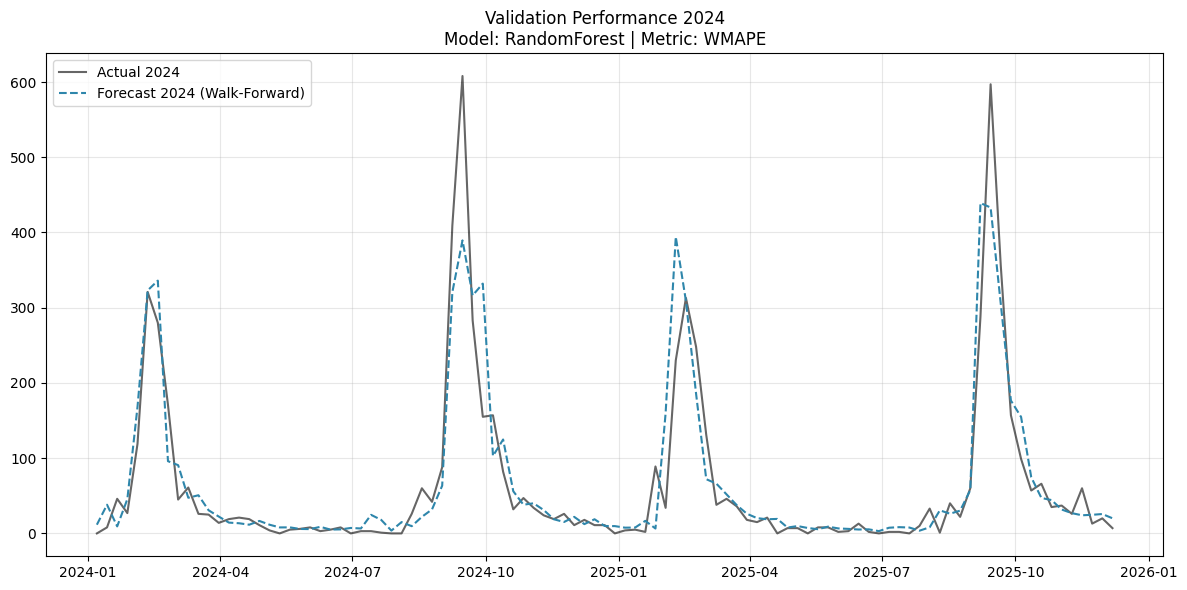

In [31]:
# Visualization of Prediction on Validation Year (2024)
print("\nGenerating validation plot...")
val_df = df_features[df_features['week_ending'].dt.year == 2024].copy()

train_df_plot = df_features[df_features['week_ending'].dt.year < 2024].copy()
df_plot_full = df_features.reset_index(drop=True)
start_idx = df_plot_full[df_plot_full['week_ending'].dt.year == 2024].index[0]
end_idx = df_plot_full.index[-1]

plot_preds = []
plot_dates = []
plot_actuals = []

for i in range(start_idx, end_idx + 1):
    # Train slice
    curr_train = df_plot_full.loc[:i-1]
    curr_test = df_plot_full.loc[[i]]

    model.fit(curr_train[selected_features], curr_train['registrations'])
    pred_raw = model.predict(curr_test[selected_features])[0]
    
    pred_abs = max(0, pred_raw)

    plot_preds.append(pred_abs)
    plot_actuals.append(df_plot_full.loc[i, 'registrations'])
    plot_dates.append(df_plot_full.loc[i, 'week_ending'])

plt.figure(figsize=(12, 6))
plt.plot(plot_dates, plot_actuals, label='Actual 2024', color='black', alpha=0.6)
plt.plot(plot_dates, plot_preds, label='Forecast 2024 (Walk-Forward)', color='#2E86AB', linestyle='--')
plt.title(f'Validation Performance 2024\nModel: {algo} | Metric: WMAPE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'validation_2024_corrected.png')
plt.show()

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_true = np.array(plot_actuals)
y_pred = np.array(plot_preds)

wmape_score = wmape(y_true, y_pred) 
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print(f"\nModel Performance Metrics (2024 Validation):")
print(f"{'-'*40}")
print(f"wMAPE : {wmape_score:.2%}")
print(f"RMSE  : {rmse:.4f}")
print(f"MAE   : {mae:.4f}")
print(f"{'-'*40}")


Model Performance Metrics (2024 Validation):
----------------------------------------
wMAPE : 38.77%
RMSE  : 48.0808
MAE   : 25.6025
----------------------------------------
